Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv

--- RAW SUBJECT MATRICES (before antisymmetrisation) ---


Subject 1 raw matrix:
3.0	3.0	3.5	6.0	7.0	7.0	7.0	6.5	6.0	5.0	5.5	3.0
2.0	5.0	6.0	6.0	4.0	6.0	

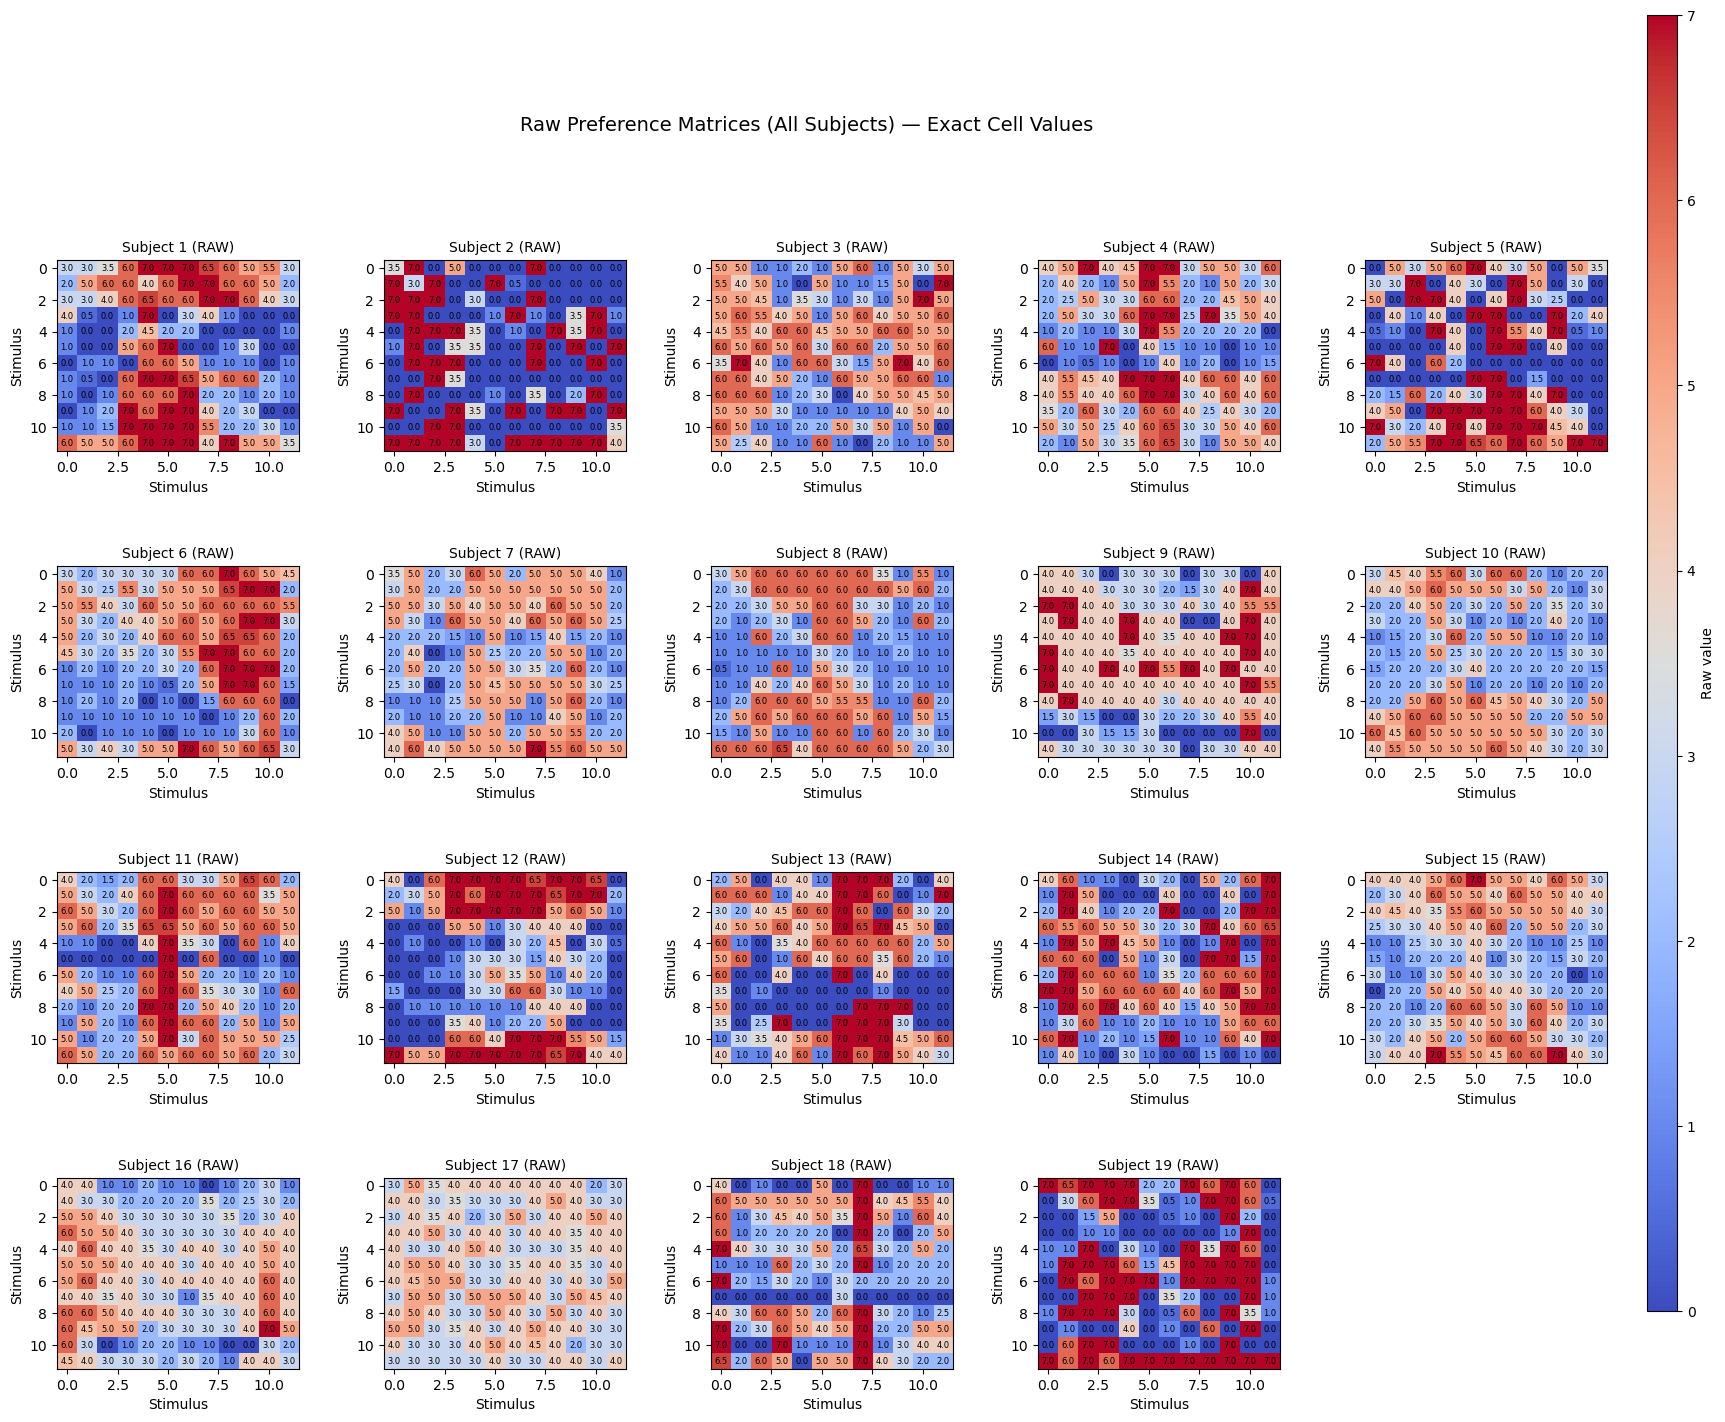

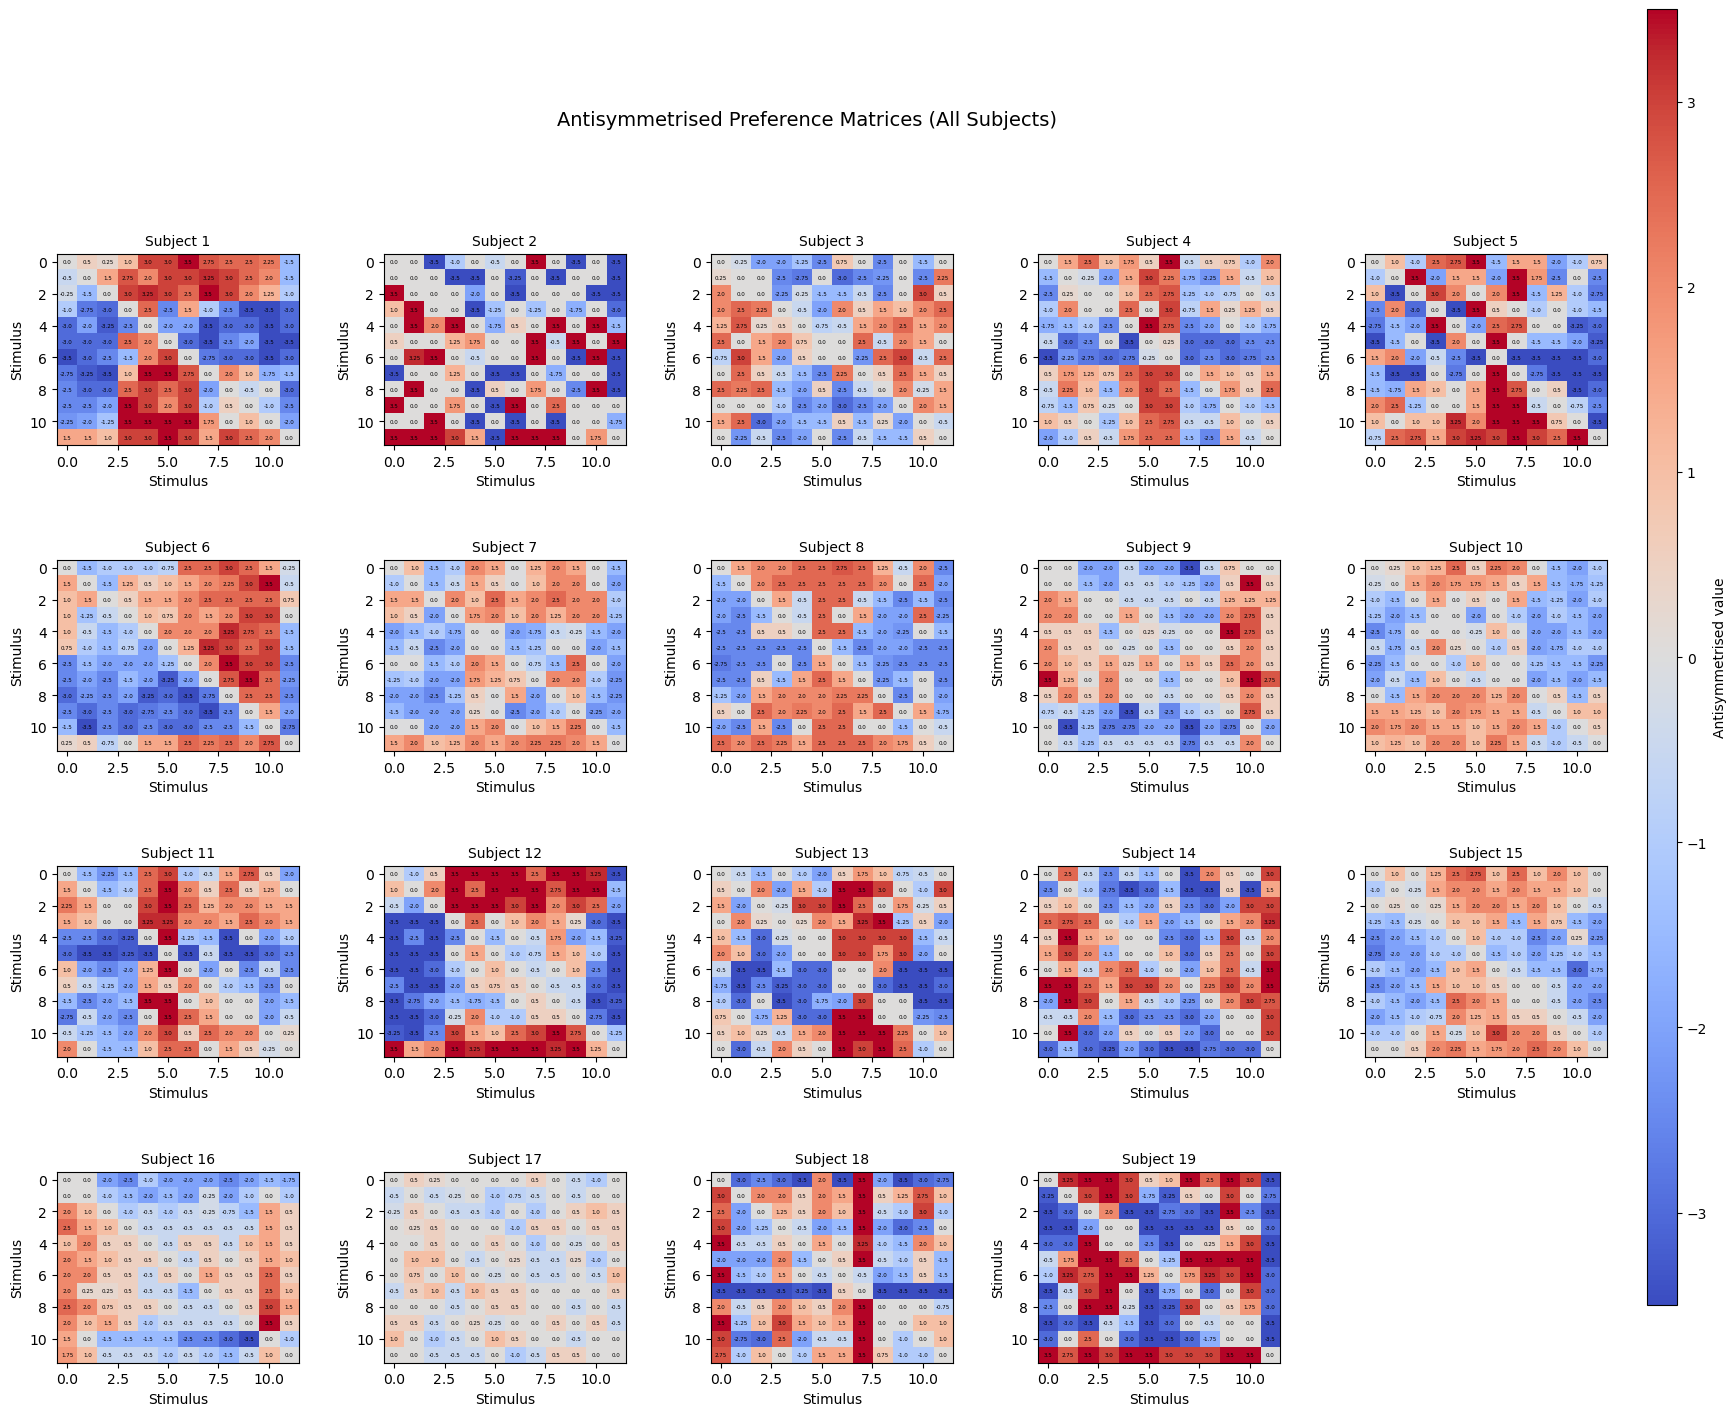

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from utilityFunctions import load_csv_to_matrix_batch

def antisymmetrise(rating_mats: np.ndarray) -> np.ndarray:
    """
    Faithful MATLAB-style antisymmetrisation.
    rating_mats: (stim x stim x participants), any numeric dtype.
    Returns float64 array of same shape.
    """
    assert rating_mats.ndim == 3, "rating_mats must be (stim x stim x participants)"
    n, m, P = rating_mats.shape
    assert n == m, "Matrices must be square."

    R = rating_mats.astype(np.float64, copy=True) 
    A = np.full((n, n, P), np.nan, dtype=np.float64)

    for p in range(P):
        for a in range(n):
            for b in range(a, n):  # include diagonal
                ab = R[a, b, p]
                ba = R[b, a, p]

                sab = np.sign(ab)
                sba = np.sign(ba)

                if sab != sba:
                    ab_mean = 0.5 * (abs(ab) + abs(ba))
                    if ab == 0:
                        ab_new = ab_mean * (-1.0 * np.sign(ba))
                        ba_new = ab_mean * np.sign(ba)
                    elif ba == 0:
                        ab_new = ab_mean * np.sign(ab)
                        ba_new = ab_mean * (-1.0 * np.sign(ab))
                    else:
                        ab_new = ab_mean * np.sign(ab)
                        ba_new = ab_mean * np.sign(ba)
                else:
                    ab_mean = 0.5 * (ab + ba)
                    ab_new  = ab - ab_mean
                    ba_new  = ba - ab_mean

                A[a, b, p] = ab_new
                A[b, a, p] = ba_new

        np.fill_diagonal(A[:, :, p], 0.0)

    return A

# ---------------------------
# Load data
# ---------------------------
folder_path = "raw_data/202411_data"  # <-- update if needed
unique_colours = np.array([
    '#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a',
    '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'
])
colour_index = {c: i for i, c in enumerate(unique_colours)}
matrix_size = len(unique_colours)

response_type = "preference"
subject_matrices_preference_raw = load_csv_to_matrix_batch(
    folder_path, response_type, colour_index, matrix_size
)

pref_raw_3d = np.stack(subject_matrices_preference_raw, axis=2).astype(np.float64, copy=False)
print("\n--- RAW SUBJECT MATRICES (before antisymmetrisation) ---\n")
for p, mat in enumerate(subject_matrices_preference_raw, start=1):
    print(f"\nSubject {p} raw matrix:")
    n, m = mat.shape
    for i in range(n):
        row_vals = [str(mat[i, j]) for j in range(m)]
        print("\t".join(row_vals))

# ---------------------------
# VISUALIZE RAW MATRICES (before antisymmetrisation)
# ---------------------------
raw_3d = np.stack(subject_matrices_preference_raw, axis=2).astype(np.float64, copy=False)

n_participants = raw_3d.shape[2]
ncols = 5
nrows = int(np.ceil(n_participants / ncols))

# Shared color scale across all raw subjects
vmin = float(np.nanmin(raw_3d))
vmax = float(np.nanmax(raw_3d))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows))
axes = np.atleast_1d(axes).ravel()

im_last = None
for p in range(n_participants):
    ax = axes[p]
    mat = raw_3d[:, :, p]

    im_last = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="coolwarm", aspect="auto")
    ax.set_title(f"Subject {p+1} (RAW)", fontsize=10)
    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Stimulus")

    # Print exact raw values (no rounding)
    n, m = mat.shape
    for i in range(n):
        for j in range(m):
            val = mat[i, j]
            ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=6)

# Hide unused axes if any
for ax in axes[n_participants:]:
    ax.axis("off")

# One shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.35, hspace=0.6)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.9])
fig.colorbar(im_last, cax=cbar_ax, label="Raw value")

plt.suptitle("Raw Preference Matrices (All Subjects) — Exact Cell Values", y=0.98, fontsize=14)
plt.show()


pref_antisym_3d = antisymmetrise(pref_raw_3d)

# ---------------------------
# Plotting
# ---------------------------
n_participants = pref_antisym_3d.shape[2]
ncols = 5
nrows = int(np.ceil(n_participants / ncols))

vmin = float(np.nanmin(pref_antisym_3d))
vmax = float(np.nanmax(pref_antisym_3d))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows))
axes = np.atleast_1d(axes).ravel()

im_last = None
for p in range(n_participants):
    ax = axes[p]
    mat = pref_antisym_3d[:, :, p]
    im_last = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="coolwarm", aspect="auto")
    ax.set_title(f"Subject {p+1}", fontsize=10)
    ax.set_xlabel("Stimulus")
    ax.set_ylabel("Stimulus")

    # Print numerical values in each cell
    n, m = mat.shape
    for i in range(n):
        for j in range(m):
            val = mat[i, j]
            ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=4)


# Hide unused axes
for ax in axes[n_participants:]:
    ax.axis("off")

# Shared colorbar
fig.subplots_adjust(right=0.90, wspace=0.35, hspace=0.6)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.9])
fig.colorbar(im_last, cax=cbar_ax, label="Antisymmetrised value")

plt.suptitle("Antisymmetrised Preference Matrices (All Subjects)", y=0.98, fontsize=14)
plt.show()